Brian Saville
June 23, 2026

Silly me! After all of this time, I've just realized that I can use notebooks to work through these chapters, learn their information, and run practice code in discrete chunks. I will try using this notebook as I continue on through Chapter 15 (the first of Project 2: Data Visualization). 

First, the work I've done so far. First, I plot a simple line graph.

In [4]:
print("What the hell")

What the hell


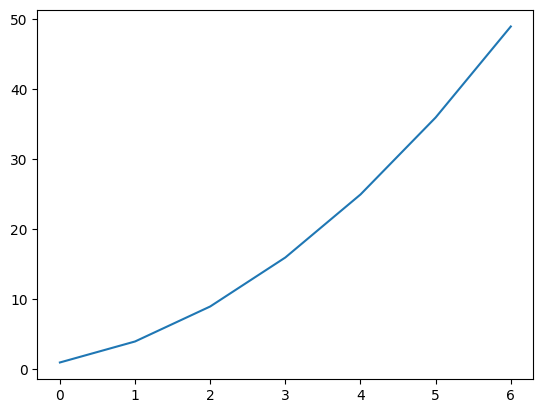

In [5]:
import matplotlib
import matplotlib.pyplot as plt

squares = [1, 4, 9, 16, 25, 36, 49]
plt.plot(squares)
plt.show()

From there, I move on to making customizations to improve readability.

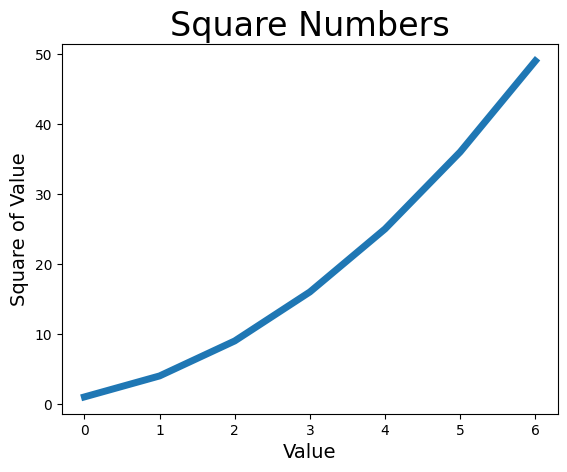

In [6]:
squares = [1, 4, 9, 16, 25, 36, 49]
plt.plot(squares, linewidth = 5)

#setting chart title and label axes
plt.title("Square Numbers", fontsize = 24)
plt.xlabel("Value", fontsize = 14)
plt.ylabel("Square of Value", fontsize = 14)

plt.show()

But the plot is not correct! To fix this, I can give both input and output values.

In [ ]:
input_values = [1, 2, 3, 4, 5, 6, 7]
squares = [1, 4, 9, 16, 25, 36, 49]
plt.plot(input_values, squares, linewidth = 5)
plt.title("Square Numbers", fontsize = 24)
plt.xlabel("Value", fontsize = 14)
plt.ylabel("Square of Value", fontsize = 14)
plt.show()

With the scatter() function, you can configure single data points individually.

In [ ]:
plt.scatter(2,4, s = 200)

plt.title("Square Numbers", fontsize = 24)
plt.xlabel("Value", fontsize = 14)
plt.ylabel("Square of Value", fontsize = 14)
plt.show()

Using scatter to plot a series of points

In [ ]:
x_values = [1, 2, 3, 4, 5]
y_values = [1, 4, 9, 16, 25]

plt.scatter(x_values, y_values, s = 100)
plt.title("Square Numbers", fontsize = 24)
plt.xlabel("Value", fontsize = 14)
plt.ylabel("Square of Value", fontsize = 14)
plt.show()

Inputting tons of data would be cumbersome. Here's one with thousands of points, but those points are calculated via formulas: 

In [ ]:
x_values = list(range(1, 1001))
y_values = [x**2 for x in x_values]

plt.scatter(x_values, y_values, s=40)

plt.title("Square Numbers", fontsize = 24)
plt.xlabel("Value", fontsize = 14)
plt.ylabel("Square of Value", fontsize = 14)

#Set the range for each axis with axis()
plt.axis([0, 1100, 0, 1100000])
plt.show()

You can also define custom colors, remove outlines.

In [ ]:
x_values = list(range(1, 1001))
y_values = [x**2 for x in x_values]

plt.scatter(x_values, y_values, c = "red", edgecolor = "none", s = 40)

plt.axis([0, 1100, 0, 1100000])
plt.show()

Can use three decimals to generate a color with an RGB color model. Neat!

In [ ]:
x_values = list(range(1, 1001))
y_values = [x**2 for x in x_values]

plt.scatter(x_values, y_values, c = (0.0, 0.6, 0.7), edgecolor = "none", s = 40)

plt.axis([0, 1100, 0, 1100000])
plt.show()

Using colormaps to visualize/ emphasize patterns in the data. Python has numerous built-in colormaps. The colormap below causes the gradient to go from light blue to dark blue.

In [ ]:
x_values = list(range(1, 1001))
y_values = [x**2 for x in x_values]

plt.scatter(x_values, y_values, c = y_values, cmap = plt.cm.Blues,
            edgecolor = "none", s = 40)

plt.axis([0, 1100, 0, 1100000])
plt.show()

Want to save your plot automatically? Replace plot.show() with plot.savefig().

Next, Random Walks. First, create a class with 3 attributes: the number of points, and the x and y coordinates of each value in the walk.

In [16]:
#creating the random walk class
from random import choice

class RandomWalk():
    """A class to generate random walks."""

    def __init__(self, num_points = 5000):
        """Initialize attributes of a walk."""
        self.num_points = num_points

        #All walks start at (0, 0)
        self.x_values = [0]
        self.y_values = [0]

    #next, a method to fill the random walk with points
    def fill_walk(self):
        """Calculate all points in the walk."""

        #Keep taking steps until walk reaches the desired length.
        while len(self.x_values) < self.num_points:
            
            #Decide which direction to go and how far to go
            x_direction = choice([1, -1])
            x_distance = choice([0, 1, 2, 3, 4])
            x_step = x_direction * x_distance

            y_direction = choice([1, -1])
            y_distance = choice([0, 1, 2, 3, 4])
            y_step = y_direction * y_distance

            #Reject steps that go nowhere.
            if x_step == 0 and y_step == 0:
                continue

            #Calculate the next x and y valyes
            next_x = self.x_values[-1] + x_step
            next_y = self.y_values[-1] + y_step

            self.x_values.append(next_x)
            self.y_values.append(next_y)

Next, plotting the random walk (not sure if I'll have to import the class when they're in different notebook chunks of the same document. Let's find out)

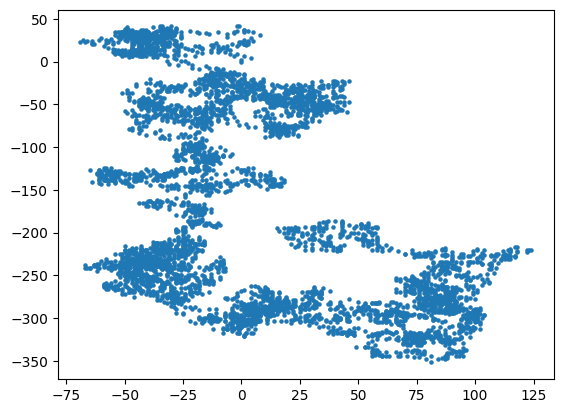

In [40]:
#make a random walk, and plot the points

rw = RandomWalk()
rw.fill_walk()

plt.scatter(rw.x_values, rw.y_values, s = 5)
plt.show()

That's really cool!

Next up, generating multiple random walks. One way is to put the code inside a while loop, asking for user input

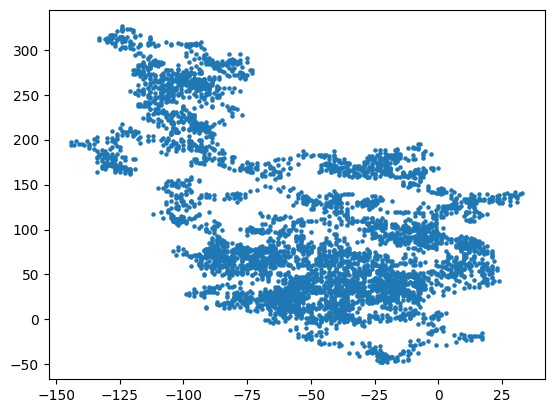

In [90]:
#Keep making new walks, as long as the program is active.
while True:
    #make a random walk, and plot the points

    rw = RandomWalk()
    rw.fill_walk()

    plt.scatter(rw.x_values, rw.y_values, s = 5)
    plt.show()

    keep_running = input("Make another walk? (y/n): ")
    if keep_running == "n":
        break

Next step is to style the walk to make it clear where the start, end, and path taken are, and not have it be just a jumble of points.

First, coloring the points by adding a colormap.

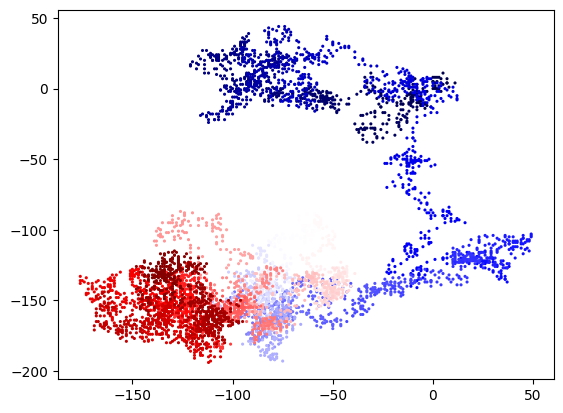

In [91]:
rw = RandomWalk()
rw.fill_walk()

point_numbers = list(range(rw.num_points))
plt.scatter(rw.x_values, rw.y_values, c=point_numbers, cmap=plt.cm.seismic,
            edgecolor = "none", s= 5)


plt.show()

Okay, that looks awesome! Next up, plotting the starting and ending points. The trick will be to plot the first and last points individually once the main series has been plotted, making them larger and differently colored for emphasis. 

In [ ]:
rw = RandomWalk()
rw.fill_walk()

point_numbers = list(range(rw.num_points))
plt.scatter(rw.x_values, rw.y_values, c=point_numbers, cmap=plt.cm.seismic,
            edgecolor = "none", s= 5)

#Emphasize the first and last points.
plt.scatter(0, 0, c = "green", edgecolors= "none", s=100)
plt.scatter(rw.x_values[-1], rw.y_values[-1], c= "red", edgecolors = "none",
            s = 100)

#remove the axes
#these don't seem to work as intended when I run them
#plt.axes().get_xaxis().set_visible(False)  
#plt.axes().get_yaxis().set_visible(False)

plt.show()

Next step is to add more points to spice things up.

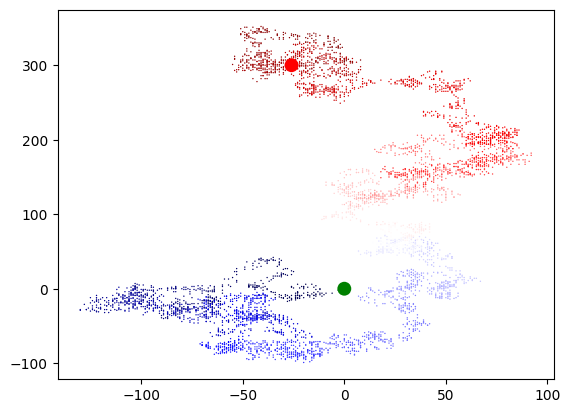

In [92]:
rw = RandomWalk()
rw.fill_walk()

point_numbers = list(range(rw.num_points))
plt.scatter(rw.x_values, rw.y_values, c=point_numbers, cmap=plt.cm.seismic,
            edgecolor = "none", s= 1)

#Emphasize the first and last points.
plt.scatter(0, 0, c = "green", edgecolors= "none", s=100)
plt.scatter(rw.x_values[-1], rw.y_values[-1], c= "red", edgecolors = "none",
            s = 100)

plt.show()

The figure() function can be used to alter the size of the plotting window, controlling the height, width, resolution, and background color of the plot.

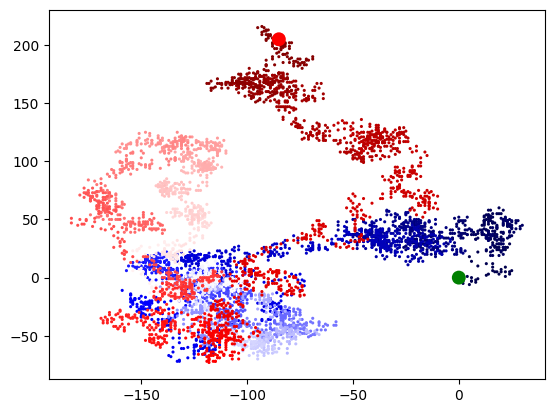

<Figure size 1000x600 with 0 Axes>

In [ ]:
rw = RandomWalk()
rw.fill_walk()

point_numbers = list(range(rw.num_points))
plt.scatter(rw.x_values, rw.y_values, c=point_numbers, cmap=plt.cm.seismic,
            edgecolor = "none", s= 5)

#Emphasize the first and last points.
plt.scatter(0, 0, c = "green", edgecolors= "none", s=100)
plt.scatter(rw.x_values[-1], rw.y_values[-1], c= "red", edgecolors = "none",
            s = 100)

plt.figure(figsize = (10,6))
#the x and y values each correspond to 100 pixels.
#you can also input dpi here like so:
#plt.figure(dpi = 128, figsize = (10,6))

plt.show()